# Assignment 7.1: Music Genre and Composer Classification Using Deep Learning

**Course**: Neural Networks and Deep Learning (AAI-511)

**Team Members**: Pros Loung, Nicole Rowley, Reema Eid

**Professor**: Kahila Mokhtari Jadid

**University of San Diego**

**GitHub Repository**: https://github.com/nicole-rowley-msaai/MS_AAI_511_Neural_Networks_DL |

**Purpose**: The purpose of this project is to develop Long Short-Term Memory (LSTM) adnd Convolutional Neural Network deep learning models that can predict the composer of a given musical score accurately.

**Dataset**: The project will use a dataset consisting of musical scores from various composers from Kaggle, https://www.kaggle.com/datasets/blanderbuss/midi-classic-music.

## Notebook 1 (Main Project Notebook):
- **Team Contribution Map**: Identify each team member’s tasks ownership.  
- **Project Pipeline**: Define the project continuous workflows and tasks required for the application.
- **Load Data and Exploration**: Load raw music-score data and labels.  Check class balance, missing labels, and duplicate samples. Establish train/validation/test split strategy with stratification.
- **Representation and Preprocessing**: Convert source files to a consistent symbolic representation. Normalize sequence length strategy (padding/truncation/windows). Build preprocessing pipeline that can be reused for inference.
- **Feature Engineering**: Build two branches of inputs: sequence-based inputs for LSTM and image/grid-like representations for CNN (if applicable). Generate optional handcrafted features (tempo, pitch range, interval stats) for comparison baselines.
- **Deep Model Development**: Develop LSTM and CNN models. LSTM track - embedding/sequence layers, recurrent blocks, dropout, and dense classifier. CNN track: convolution blocks, pooling, normalization, and dense classifier.
- **Training and Validation**: Use early stopping and model checkpointing. Run controlled experiments across learning rate, batch size, depth, and dropout. Track every run with config, metrics, and notes.
- **Evaluation and Error Analysis**: Evaluate best models on hold-out test set. Report accuracy, precision, recall, F1-score, and confusion matrix. Analyze frequent misclassifications and class-specific weaknesses.
-- **Model Selection and Optimization**: Compare LSTM vs CNN against objective metrics and training stability. Select final model using both metric quality and robustness. Apply final hyperparameter tuning pass
-- **Packaging and Reproducibility**: Save preprocessing artifacts, label encoder, and model weights. Create an inference function for unseen music input. Document end-to-end run steps for reproducibility
- **Final Deliverables**: Final notebook with narrative, visual results. problem, method, results, limitations, future work.

## Notebook 2 (logistic_regression_pipeline.py):

This notebook contains the codes for Logistic Regression model. This model serves as the baseline model for evaluation comparsion for deep learning models - LSTM and CNN. This is imported and used in the Notebook 1, Section 5.1.

## Team Contribution Map

| <div align="center"> Team Member </div> | <div align="center"> Workstream </div> | <div align="center"> Sections Owned </div> |
|---|---|---|
| **Pros** | Project Setup, proect pipeline, load data & exploration, representation & preprocessing, feature engineering, baseline model - Logistic Regression| Sections 1 - 5 |
| **Nicole** | |  |
| **Reema** |  | |
| **Team** | Final validation, Final Report, and GitHub submission | Notebook 2 final report sections and presentation |

## Project Pipeline Diagram

```mermaid
flowchart TD
    A[1. Project Setup] --> B[2. Load Data and Exploration]
    B --> C[3. Representation and Preprocessing]
    C --> D[4. Feature Engineering]
    D --> F[5. Deep Model Development<br/>LSTM and CNN Tracks<br/>Training, Validation, and Error Analysis]
    F --> I[6. Model Selection and Optimization]
    I --> J[7. Packaging and Reproducibility]
    J --> K[8. Final Deliverables]

    F -. Compare architectures .-> I
    F -. Feedback loop for improvements .-> C
    I -. Retune if needed .-> F
```

## 1.0 Project Setup
### Owner: Pros

In [1]:
# Uncomment to install libraries
#!pip install pretty_midi
#!pip install kagglehub
#!pip install pygame
#!pip install pyarrow

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import zipfile
import torch
import torch.nn as nn
import pretty_midi

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict, Tuple
from pathlib import Path
from collections import Counter

### Local Machine-only setup

Use this version only when running notebook on local machine / computer. 

In [2]:
# Run this section if using local computer
from pathlib import Path
import kagglehub

# 1 - Set the data root directory and paths for the dataset. Update the path below to point to the location of your dataset on your local machine
data_root = Path(r"C:\Users\Loung\USD\AAI-551 Neural Networks\MS_AAI_511_Neural_Networks_DL")
zip_path = data_root / "midiclassics.zip"
extract_root = data_root / "midiclassics_extracted"

# 2 - Download dataset from Kaggle
path = kagglehub.dataset_download("blanderbuss/midi-classic-music")

print("Path to dataset files:", path)

if not zip_path.exists():
    raise FileNotFoundError(f"Could not find dataset archive: {zip_path}")

if not extract_root.exists():
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_root)

c:\Users\Loung\USD\AAI-551 Neural Networks\MS_AAI_511_Neural_Networks_DL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Loung\.cache\kagglehub\datasets\blanderbuss\midi-classic-music\versions\1


### Colab-only setup
Use this version only when running the notebook in Google Colab. It keeps the dataset in Drive or in the Colab runtime cache.

In [ ]:
# SECTION 2: Kaggle API Method
# Requires KAGGLE_USERNAME and KAGGLE_KEY saved in Colab Secrets

import os
from pathlib import Path
from google.colab import userdata # This module is used to access Colab Secrets for secure authentication

# 1. Authenticate securely using Colab Secrets
try:
    os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
    os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
except userdata.SecretNotFoundError:
    print("Error: Please set KAGGLE_USERNAME and KAGGLE_KEY in Colab Secrets (the 🔑 icon on the left).")

# 2. Define the local extraction path in Colab
extract_root = Path("/content/midi-classic-music") / "midiclassics"
extract_root.mkdir(parents=True, exist_ok=True)

# 3. Download and unzip the dataset directly via Kaggle API
!kaggle datasets download -d blanderbuss/midi-classic-music -p {extract_root} --unzip

print(f"Dataset successfully downloaded and extracted to: {extract_root}")

# 4. Display the extracted files and folders
print("\nExtracted contents:")
for item in sorted(extract_root.rglob("*")):
    if item.is_file():
        print(item.relative_to(extract_root))
    elif item.is_dir():
        print(f"[DIR] {item.relative_to(extract_root)}")


**NEW**: Sections 3 and 4 previously used different fs values (100 vs 50), which corrupted the target-length calculation. Everything now reads from here:

In [3]:
# single source of truth for preprocessing constants
FS = 50                  # piano-roll sampling rate (frames/sec) — used EVERYWHERE
WINDOW_SIZE = 1024       # frames per window (~20.5 s at fs=50)
WINDOW_HOP = 512         # 50% overlap
MAX_ROLL_SECONDS = 900   # cap per piece (15 min)
LENGTH_PERCENTILE = 95.0
SEED = 42

## 2. Load Data and Exploration
### Onwer: Pros

- Load raw music-score data and labels.
- Check class balance, missing labels, and duplicate samples.
- Establish train/validation/test split strategy with stratification.

In [ ]:
# Load, validate, and split MIDI files — metadata only (PrettyMIDI objects are not retained)
# Ensure extract_root points to the correct directory containing composer folders.
# The dataset is extracted to /content/midi-classic-music, with composer files nested in a 'midiclassics' subfolder.

num_files_to_load = None # Set to an integer to limit the number of files loaded on local machine (for testing). Set to None to load all files.
target_composers = ["Bach", "Beethoven", "Chopin", "Mozart"]
SEED = 42
target_composers_lower = {name.lower() for name in target_composers}

composer_files = []
for composer_dir in extract_root.iterdir():
    if not composer_dir.is_dir() or composer_dir.name.lower() not in target_composers_lower:
        continue
    for midi_file in sorted(composer_dir.rglob("*.mid")):
        composer_files.append({"path": str(midi_file), "composer": composer_dir.name})

if not composer_files:
    raise ValueError("No target composer MIDI files were found.")

# Validation pass: parse each file ONCE, record lightweight metadata, discard object
valid_files, load_errors = [], []
for record in composer_files:
    try:
        pm = pretty_midi.PrettyMIDI(record["path"])
        record["duration"] = float(pm.get_end_time())
        record["n_notes"] = sum(len(inst.notes) for inst in pm.instruments)
        valid_files.append(record)
        del pm                                   # <- the point: nothing retained
    except Exception as e:
        load_errors.append((record["path"], str(e)))

composer_files = valid_files

# (optional stratified subsample block: UNCHANGED)

labels = [item["composer"].lower() for item in composer_files]
train_records, temp_records = train_test_split(
    composer_files, test_size=0.30, random_state=SEED, stratify=labels)
temp_labels = [item["composer"].lower() for item in temp_records]
dev_records, test_records = train_test_split(
    temp_records, test_size=0.50, random_state=SEED, stratify=temp_labels)

split_records = {"train": train_records, "dev": dev_records, "test": test_records}

split_class_counts = {
    split: Counter(item["composer"] for item in records)
    for split, records in split_records.items()
}

print(f"In-scope MIDI files (validated): {len(composer_files)}")
for split in ["train", "dev", "test"]:
    print(f"{split.upper()}: {len(split_records[split])}  "
          f"{dict(split_class_counts[split])}")
if load_errors:
    print(f"\nFiles with load errors: {len(load_errors)}")
    for p, e in load_errors[:5]:
        print(f"  - {p}: {e}")

c:\Users\Loung\USD\AAI-551 Neural Networks\MS_AAI_511_Neural_Networks_DL\.venv\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


In-scope MIDI files (validated): 1628
TRAIN: 1139  {'Bach': 717, 'Chopin': 95, 'Mozart': 179, 'Beethoven': 148}
DEV: 244  {'Bach': 153, 'Chopin': 21, 'Mozart': 38, 'Beethoven': 32}
TEST: 245  {'Bach': 154, 'Beethoven': 32, 'Chopin': 20, 'Mozart': 39}

Files with load errors: 2
  - C:\Users\Loung\USD\AAI-551 Neural Networks\MS_AAI_511_Neural_Networks_DL\midiclassics_extracted\Beethoven\Anhang 14-3.mid: Could not decode key with 3 flats and mode 255
  - C:\Users\Loung\USD\AAI-551 Neural Networks\MS_AAI_511_Neural_Networks_DL\midiclassics_extracted\Mozart\Piano Sonatas\Nueva carpeta\K281 Piano Sonata n03 3mov.mid: Could not decode key with 2 flats and mode 2


EDA summary only ever uses aggregates (counts, means, mins, maxes per composer) plus tempo/time-sig values. So don't materialize the raw event table at all — accumulate compact per-event tuples into typed lists, and skip the redundant strings by storing a file index:

In [6]:
# Exploratory Data Analysis (EDA) of MIDI files — optimized single pass with cache

import mido

eda_cache_dir = Path("artifacts/eda")
eda_cache_dir.mkdir(parents=True, exist_ok=True)
note_cache = eda_cache_dir / "note_df.parquet"
tempo_cache = eda_cache_dir / "tempo_df.parquet"
ts_cache = eda_cache_dir / "ts_df.parquet"

if note_cache.exists() and tempo_cache.exists() and ts_cache.exists():
    # Cached run: skip the expensive mido parsing entirely
    note_df = pd.read_parquet(note_cache)
    tempo_df = pd.read_parquet(tempo_cache)
    ts_df = pd.read_parquet(ts_cache)
    print(f"Loaded EDA frames from cache ({eda_cache_dir})\n")
else:
    # Fresh run: single pass over the train split with mido
    note_pitch, note_vel, note_file = [], [], []   # parallel flat lists (ints only)
    tempo_rows, ts_rows = [], []                    # (file_idx, value) tuples
    file_meta = []                                  # one entry per file

    for file_idx, record in enumerate(split_records["train"]):
        midi_path = record["path"]
        file_meta.append((midi_path, record["composer"]))
        try:
            mid = mido.MidiFile(midi_path)
            for track in mid.tracks:
                for msg in track:
                    t = msg.type
                    if t == "note_on" and msg.velocity > 0:   # true onsets only
                        note_pitch.append(msg.note)
                        note_vel.append(msg.velocity)
                        note_file.append(file_idx)
                    elif t == "set_tempo":
                        tempo_rows.append((file_idx, mido.tempo2bpm(msg.tempo)))
                    elif t == "time_signature":
                        ts_rows.append((file_idx, msg.numerator, msg.denominator))
        except Exception as e:
            print(f"Error processing {midi_path}: {e}")

    # Compact typed frames — composer attached via file index, not repeated strings
    meta_df = pd.DataFrame(file_meta, columns=["file", "composer"])

    note_df = pd.DataFrame({
        "pitch": np.array(note_pitch, dtype=np.int16),
        "velocity": np.array(note_vel, dtype=np.int16),
        "file_idx": np.array(note_file, dtype=np.int32),
    })
    note_df["composer"] = meta_df["composer"].reindex(note_df["file_idx"]).values
    note_df["composer"] = note_df["composer"].astype("category")

    tempo_df = pd.DataFrame(tempo_rows, columns=["file_idx", "bpm"])
    tempo_df["composer"] = meta_df["composer"].reindex(tempo_df["file_idx"]).values
    tempo_df["composer"] = tempo_df["composer"].astype("category")

    ts_df = pd.DataFrame(ts_rows, columns=["file_idx", "numerator", "denominator"])
    ts_df["composer"] = meta_df["composer"].reindex(ts_df["file_idx"]).values
    ts_df["composer"] = ts_df["composer"].astype("category")

    # Persist so reruns in this session (and exports) are instant
    note_df.to_parquet(note_cache)
    tempo_df.to_parquet(tempo_cache)
    ts_df.to_parquet(ts_cache)
    print(f"Parsed {len(file_meta)} files; cached EDA frames to {eda_cache_dir}\n")

# ---------------------------------------------------------------------------
# EDA summary — computed from the data
# ---------------------------------------------------------------------------
print("EDA Summary (computed from train split)")
print("-" * 60)
print(f"Files scanned: {note_df['file_idx'].nunique()}")
print(f"Total note onsets: {len(note_df):,}")

print(f"\nNote onsets per composer:")
print(note_df["composer"].value_counts().to_string())

print(f"\nGlobal pitch range: {int(note_df['pitch'].min())}–{int(note_df['pitch'].max())} (MIDI note numbers)")

print(f"\nPitch statistics by composer:")
print(note_df.groupby("composer", observed=True)["pitch"]
      .agg(["mean", "std", "min", "max"]).round(1).to_string())

print(f"\nVelocity statistics by composer:")
print(note_df.groupby("composer", observed=True)["velocity"]
      .agg(["mean", "std"]).round(1).to_string())

if not tempo_df.empty:
    print(f"\nTempo (BPM) statistics by composer:")
    print(tempo_df.groupby("composer", observed=True)["bpm"]
          .agg(["mean", "median", "min", "max"]).round(1).to_string())

if not ts_df.empty:
    ts_df["signature"] = (
        ts_df["numerator"].astype(int).astype(str)
        + "/"
        + ts_df["denominator"].astype(int).astype(str)
    )
    print(f"\nMost common time signatures (all composers):")
    print(ts_df["signature"].value_counts().head(5).to_string())

Loaded EDA frames from cache (artifacts\eda)

EDA Summary (computed from train split)
------------------------------------------------------------
Files scanned: 1139
Total note onsets: 3,624,190

Note onsets per composer:
composer
Bach         1252983
Beethoven    1122090
Mozart       1035846
Chopin        213271

Global pitch range: 9–105 (MIDI note numbers)

Pitch statistics by composer:
           mean   std  min  max
composer                       
Bach       63.9  11.1   12  102
Beethoven  63.7  13.3    9  105
Chopin     64.0  13.1   23  102
Mozart     64.7  12.0   17  101

Velocity statistics by composer:
           mean   std
composer             
Bach       86.8  19.4
Beethoven  79.9  27.0
Chopin     71.6  27.3
Mozart     79.3  23.1

Tempo (BPM) statistics by composer:
            mean  median  min    max
composer                            
Bach        91.0    85.0  8.0  254.0
Beethoven  133.8   124.0  5.0  460.0
Chopin     108.4    99.8  8.0  451.0
Mozart     108.1   116.0  

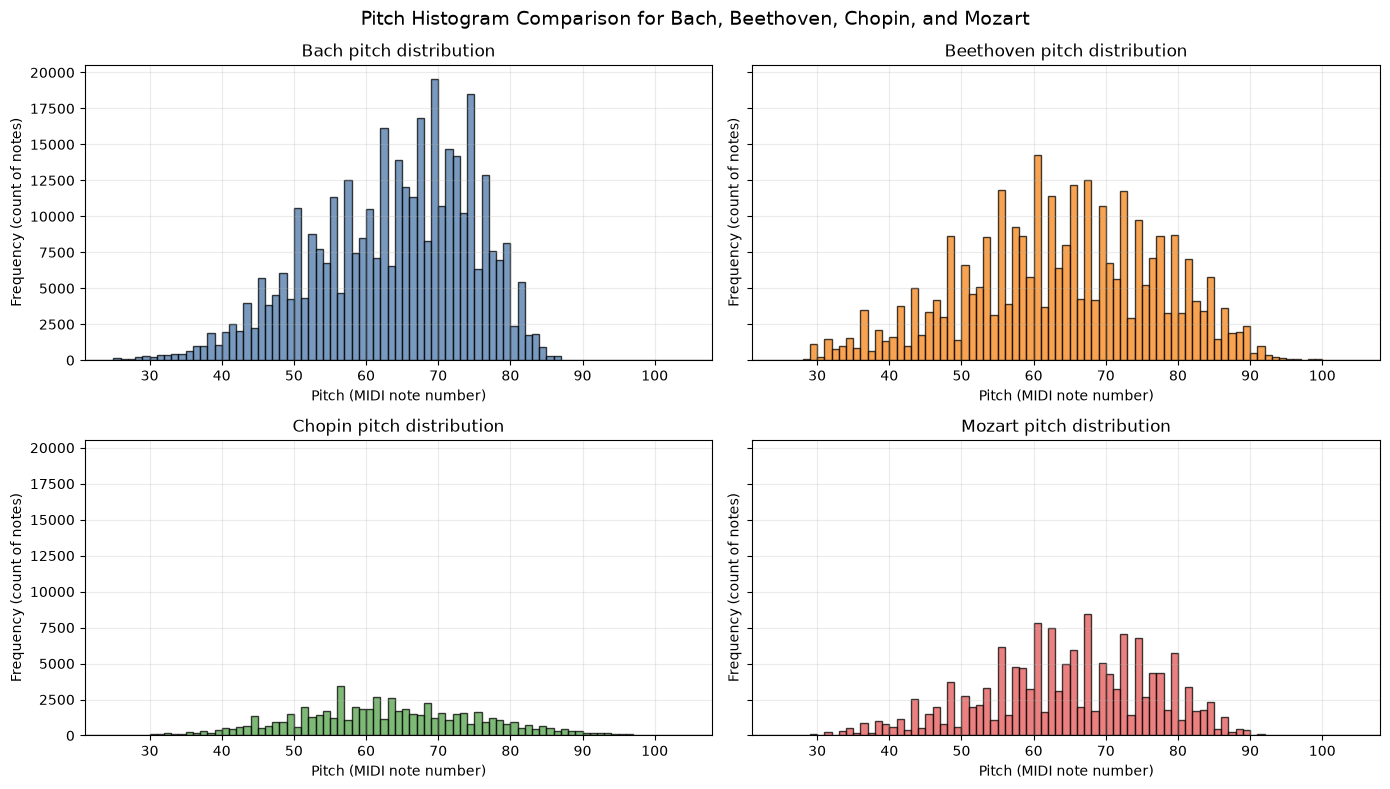

<Figure size 640x480 with 0 Axes>

In [11]:
import matplotlib.pyplot as plt

# Compare pitch distributions for the selected composers
composers = ["Bach", "Beethoven", "Chopin", "Mozart"]
colors = {"Bach": "#4c78a8", "Beethoven": "#f58518", "Chopin": "#54a24b", "Mozart": "#e45756"}

pitch_by_composer = {composer: [] for composer in composers}

for record in split_records["dev"]:
    composer = record["composer"]
    if composer not in composers:
        continue

    midi_path = record["path"]
    try:
        mid = mido.MidiFile(midi_path)
        for track in mid.tracks:
            for msg in track:
                if msg.type in {"note_on", "note_off"} and getattr(msg, "velocity", 0) > 0:
                    pitch_by_composer[composer].append(msg.note)
    except Exception as e:
        print(f"Error processing {midi_path}: {e}")

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
axes = axes.flatten()

for ax, composer in zip(axes, composers):
    pitches = pitch_by_composer[composer]
    if pitches:
        ax.hist(pitches, bins=range(21, 129), alpha=0.75, color=colors[composer], edgecolor="black")
        ax.set_title(f"{composer} pitch distribution")
        ax.set_xlabel("Pitch (MIDI note number)")
        ax.set_ylabel("Frequency (count of notes)")
    else:
        ax.text(0.5, 0.5, "No note data available", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{composer}")
        ax.set_xlabel("Pitch (MIDI note number)")
        ax.set_ylabel("Frequency (count of notes)")
    ax.set_xlim(21, 108)
    ax.grid(alpha=0.25)

fig.suptitle("Pitch Histogram Comparison for Bach, Beethoven, Chopin, and Mozart", fontsize=14)
plt.tight_layout()
plt.show()

plt.savefig("artifacts/pitch_histogram_comparison.png", dpi=300, bbox_inches="tight")

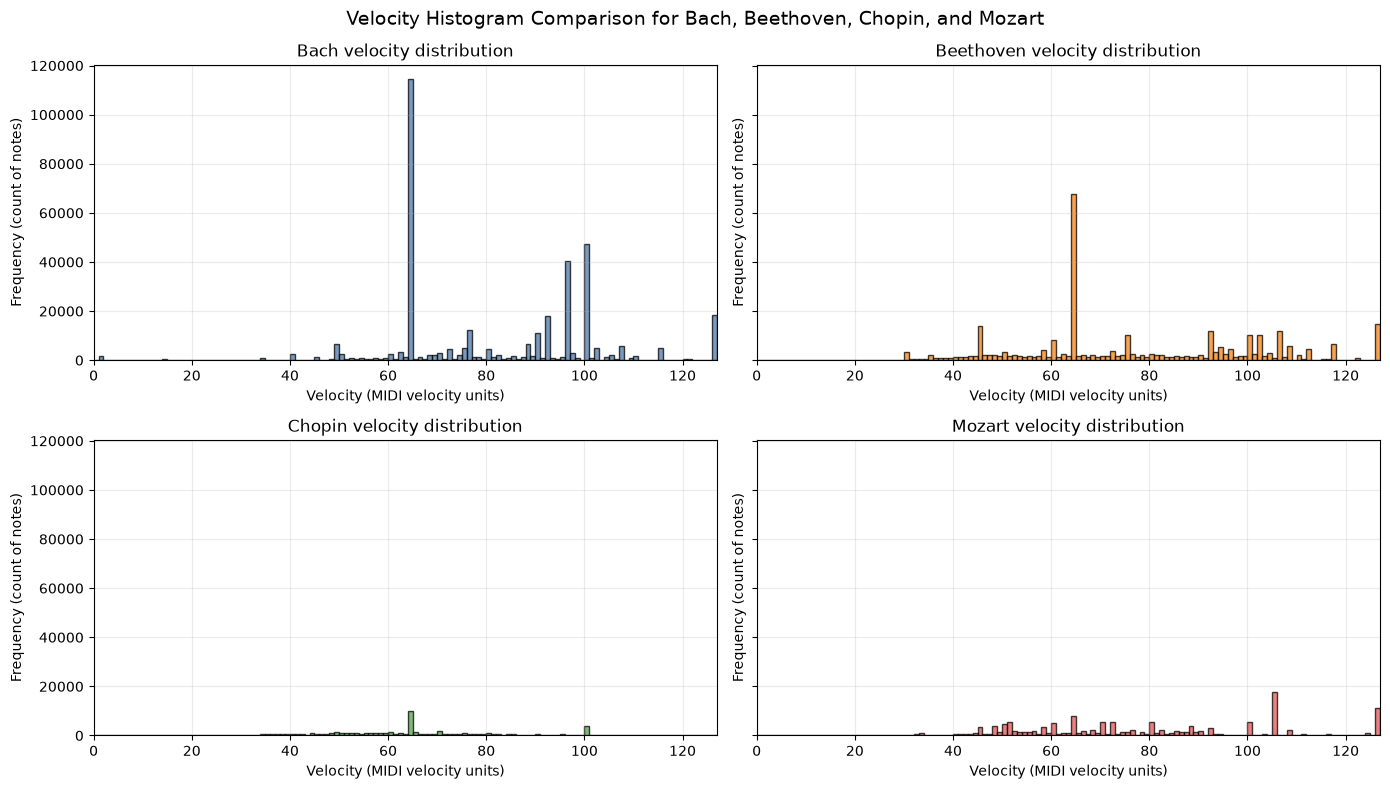

<Figure size 640x480 with 0 Axes>

In [12]:
# Comparing velocity distributions for the selected composers
velocity_by_composer = {composer: [] for composer in composers}

for record in split_records["dev"]:
    composer = record["composer"]
    if composer not in composers:
        continue

    midi_path = record["path"]
    try:
        mid = mido.MidiFile(midi_path)
        for track in mid.tracks:
            for msg in track:
                if msg.type in {"note_on", "note_off"} and getattr(msg, "velocity", 0) > 0:
                    velocity_by_composer[composer].append(msg.velocity)
    except Exception as e:
        print(f"Error processing {midi_path}: {e}")

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
axes = axes.flatten()

for ax, composer in zip(axes, composers):
    velocities = velocity_by_composer[composer]
    if velocities:
        ax.hist(velocities, bins=range(0, 128), alpha=0.75, color=colors[composer], edgecolor="black")
        ax.set_title(f"{composer} velocity distribution")
        ax.set_xlabel("Velocity (MIDI velocity units)")
        ax.set_ylabel("Frequency (count of notes)")
    else:
        ax.text(0.5, 0.5, "No velocity data available", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{composer}")
        ax.set_xlabel("Velocity (MIDI velocity units)")
        ax.set_ylabel("Frequency (count of notes)")
    ax.set_xlim(0, 127)
    ax.grid(alpha=0.25)

fig.suptitle("Velocity Histogram Comparison for Bach, Beethoven, Chopin, and Mozart", fontsize=14)
plt.tight_layout()
plt.show()

plt.savefig("artifacts/velocity_histogram_comparison.png", dpi=300, bbox_inches="tight")

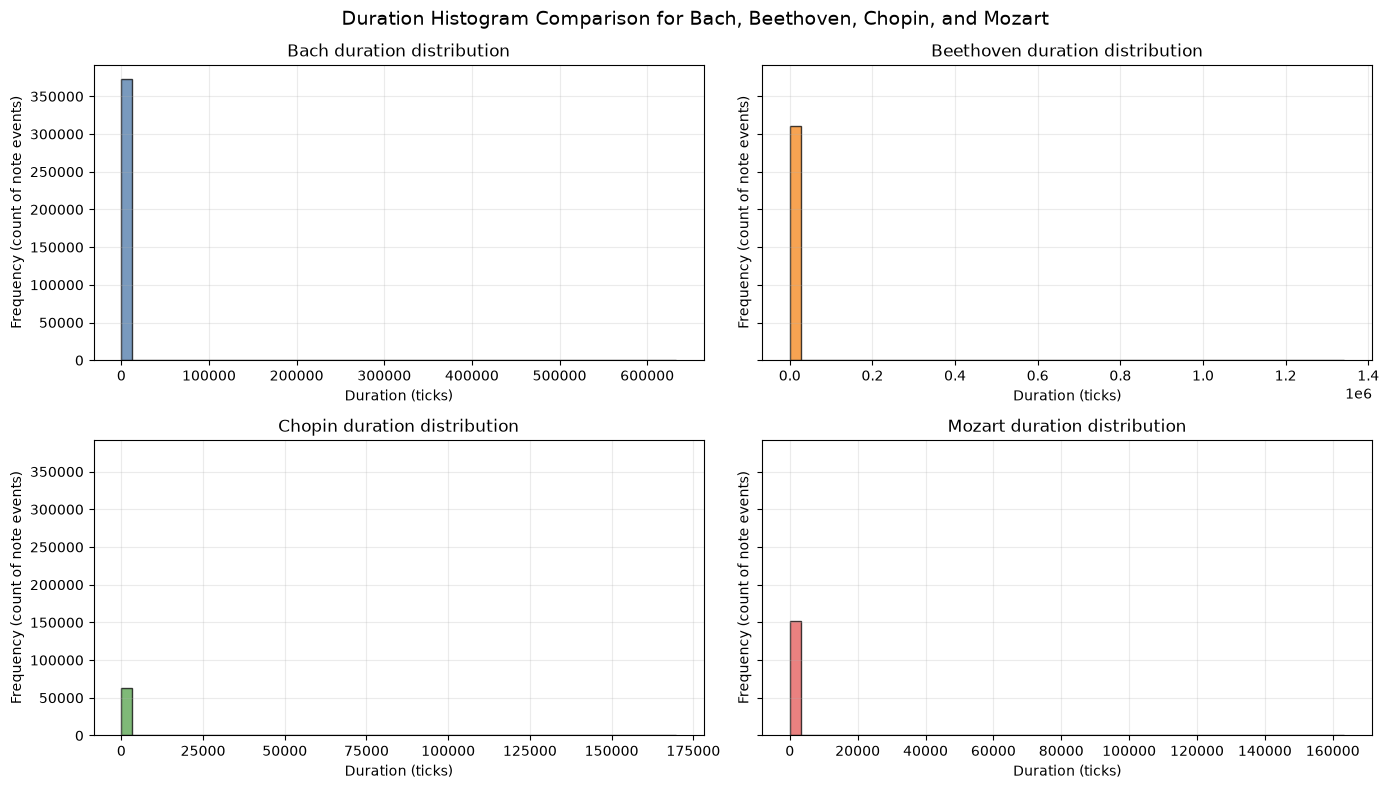

<Figure size 640x480 with 0 Axes>

In [13]:
# Comparing duration distributions for the selected composers
duration_by_composer = {composer: [] for composer in composers}

for record in split_records["dev"]:
    composer = record["composer"]
    if composer not in composers:
        continue

    midi_path = record["path"]
    try:
        mid = mido.MidiFile(midi_path)
        for track in mid.tracks:
            for msg in track:
                if msg.type in {"note_on", "note_off"} and getattr(msg, "velocity", 0) > 0:
                    duration_by_composer[composer].append(msg.time)
    except Exception as e:
        print(f"Error processing {midi_path}: {e}")

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
axes = axes.flatten()

for ax, composer in zip(axes, composers):
    durations = duration_by_composer[composer]
    if durations:
        ax.hist(durations, bins=50, alpha=0.75, color=colors[composer], edgecolor="black")
        ax.set_title(f"{composer} duration distribution")
        ax.set_xlabel("Duration (ticks)")
        ax.set_ylabel("Frequency (count of note events)")
    else:
        ax.text(0.5, 0.5, "No duration data available", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{composer}")
        ax.set_xlabel("Duration (ticks)")
        ax.set_ylabel("Frequency (count of note events)")
    ax.grid(alpha=0.25)

fig.suptitle("Duration Histogram Comparison for Bach, Beethoven, Chopin, and Mozart", fontsize=14)
plt.tight_layout()
plt.show()

plt.savefig("artifacts/duration_histogram_comparison.png", dpi=300, bbox_inches="tight")

c:\Users\Loung\USD\AAI-551 Neural Networks\MS_AAI_511_Neural_Networks_DL\.venv\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


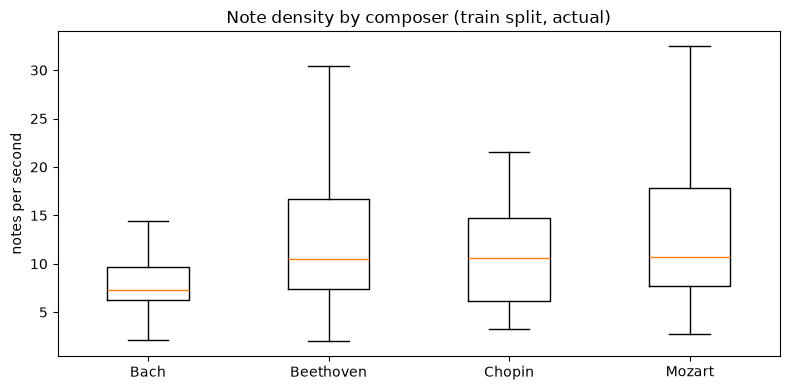

<Figure size 640x480 with 0 Axes>

In [15]:
# Temporal texture measure (notes/sec per file).
density_rows = []
for record in split_records["train"]:
    try:
        pm = pretty_midi.PrettyMIDI(record["path"])
        n_notes = sum(len(inst.notes) for inst in pm.instruments)
        dur = pm.get_end_time()
        if dur > 0:
            density_rows.append({"composer": record["composer"],
                                 "notes_per_sec": n_notes / dur})
    except Exception:
        continue

density_df = pd.DataFrame(density_rows)
fig, ax = plt.subplots(figsize=(8, 4))
data = [density_df.loc[density_df.composer == c, "notes_per_sec"] for c in target_composers]
bp = ax.boxplot(data, showfliers=False)
ax.set_xticks(range(1, len(data) + 1))
ax.set_xticklabels(target_composers)
ax.set_ylabel("notes per second")
ax.set_title("Note density by composer (train split, actual)")

plt.tight_layout()
plt.show()
plt.savefig("artifacts/note_density_by_composer.png", dpi=300, bbox_inches="tight")

In [16]:
# Preview one dev file as synthesized audio (parses just this one file on demand)
from IPython.display import Audio, display

sample_record = split_records["dev"][10]
pm_preview = pretty_midi.PrettyMIDI(sample_record["path"])

sample_rate = 16000
display(Audio(pm_preview.synthesize(fs=sample_rate), rate=sample_rate))
print(f"Audio preview: {sample_record['composer']} — {sample_record['path']}")

del pm_preview  # release immediately; don't retain parsed objects

Audio preview: Bach — C:\Users\Loung\USD\AAI-551 Neural Networks\MS_AAI_511_Neural_Networks_DL\midiclassics_extracted\Bach\Bwv001- 400 Chorales\018405bv.mid


In [17]:
# Split-level summary: durations and note counts from stored metadata
# (no parsing, no PrettyMIDI objects — reads fields recorded in Cell 15)

def summarize_split(split_name, records):
    if not records:
        print(f"{split_name.upper()}: empty")
        return

    durations = np.array([r["duration"] for r in records])
    note_counts = np.array([r["n_notes"] for r in records])

    frames = durations * FS  # frame counts at the pipeline's actual fs
    print(f"\n{split_name.upper()}  ({len(records)} files)")
    print(f"  duration (s)   min/median/max: "
          f"{durations.min():.0f} / {np.median(durations):.0f} / {durations.max():.0f}")
    print(f"  frames @fs={FS} min/median/max: "
          f"{frames.min():.0f} / {np.median(frames):.0f} / {frames.max():.0f}"
          f"   (window={WINDOW_SIZE}, hop={WINDOW_HOP})")
    print(f"  notes per file min/median/max: "
          f"{note_counts.min()} / {int(np.median(note_counts))} / {note_counts.max()}")

    # Flag suspiciously sparse files (possible corrupt/stub MIDIs)
    sparse = note_counts < 50
    if sparse.any():
        print(f"  ⚠ {sparse.sum()} file(s) with <50 notes — inspect for corrupt/stub data")

    # Report how many files the duration cap will actually truncate
    capped = durations > MAX_ROLL_SECONDS
    if capped.any():
        print(f"  {capped.sum()} file(s) exceed the {MAX_ROLL_SECONDS}s cap (will be truncated)")

for name in ["train", "dev", "test"]:
    summarize_split(name, split_records[name])


TRAIN  (1139 files)
  duration (s)   min/median/max: 20 / 132 / 2500
  frames @fs=50 min/median/max: 1000 / 6600 / 124998   (window=1024, hop=512)
  notes per file min/median/max: 83 / 1144 / 47745
  48 file(s) exceed the 900s cap (will be truncated)

DEV  (244 files)
  duration (s)   min/median/max: 18 / 158 / 5209
  frames @fs=50 min/median/max: 875 / 7906 / 260466   (window=1024, hop=512)
  notes per file min/median/max: 90 / 1353 / 44853
  6 file(s) exceed the 900s cap (will be truncated)

TEST  (245 files)
  duration (s)   min/median/max: 22 / 123 / 5032
  frames @fs=50 min/median/max: 1093 / 6136 / 251615   (window=1024, hop=512)
  notes per file min/median/max: 99 / 1166 / 26014
  9 file(s) exceed the 900s cap (will be truncated)


## 3. Representation and Preprocessing
### Owner: Pros
- Convert source files to a consistent symbolic representation.
- Normalize sequence length strategy (padding/truncation/windows).
- Build preprocessing pipeline that can be reused for inference.

In [18]:
# Reusable MIDI preprocessing pipeline

@dataclass
class MidiPreprocessorConfig:
    fs: int = FS                            # from shared constants (50 Hz)
    velocity_scale: float = 127.0
    length_percentile: float = LENGTH_PERCENTILE
    window_size: int = WINDOW_SIZE          # frames per window
    window_hop: int = WINDOW_HOP            # frames between window starts
    use_windows: bool = True
    max_seconds: float = MAX_ROLL_SECONDS   # duration cap per piece (15 min)


class MidiPreprocessor:
    def __init__(self, config: MidiPreprocessorConfig):
        self.config = config
        self.target_seconds_ = None  # fitted target length in SECONDS (fs-independent)

    @property
    def target_length_(self):
        """Target length in frames, derived from seconds at the configured fs."""
        if self.target_seconds_ is None:
            return None
        return max(1, int(self.target_seconds_ * self.config.fs))

    def to_symbolic(self, pm: pretty_midi.PrettyMIDI) -> np.ndarray:
        """Consistent symbolic representation: velocity-normalized piano roll,
        duration-capped to max_seconds. Returns (128, T)."""
        end = min(float(pm.get_end_time()), self.config.max_seconds)
        if end <= 0:
            return np.zeros((128, 1), dtype=np.float32)

        n_steps = max(1, int(self.config.fs * end))
        times = np.linspace(0.0, end, num=n_steps, endpoint=False)

        try:
            roll = pm.get_piano_roll(times=times).astype(np.float32)
        except MemoryError:
            # Fallback with reduced resolution if a file is still too large
            safe_fs = max(10, self.config.fs // 2)
            n_steps = max(1, int(safe_fs * end))
            times = np.linspace(0.0, end, num=n_steps, endpoint=False)
            roll = pm.get_piano_roll(times=times).astype(np.float32)

        roll /= self.config.velocity_scale
        return np.clip(roll, 0.0, 1.0)

    def fit(self, midi_list: List[pretty_midi.PrettyMIDI]):
        """Fit target length (in seconds) as a percentile of capped piece
        durations. Cheap: reads end times only, builds no piano rolls."""
        secs = [
            min(float(pm.get_end_time()), self.config.max_seconds)
            for pm in midi_list
        ]
        if not secs:
            raise ValueError("fit() received an empty MIDI list.")
        self.target_seconds_ = float(
            np.percentile(secs, self.config.length_percentile)
        )
        return self

    def _pad_or_truncate(self, seq: np.ndarray) -> np.ndarray:
        if self.target_length_ is None:
            raise RuntimeError("Call fit() before transform()")

        t = seq.shape[1]
        if t < self.target_length_:
            pad = np.zeros((128, self.target_length_ - t), dtype=np.float32)
            seq = np.concatenate([seq, pad], axis=1)
        elif t > self.target_length_:
            seq = seq[:, :self.target_length_]
        return seq

    def _window(self, seq: np.ndarray) -> np.ndarray:
        ws = self.config.window_size
        hop = self.config.window_hop
        if ws <= 0 or hop <= 0:
            raise ValueError("window_size and window_hop must be > 0")

        if seq.shape[1] < ws:
            pad = np.zeros((128, ws - seq.shape[1]), dtype=np.float32)
            seq = np.concatenate([seq, pad], axis=1)

        windows = []
        for start in range(0, seq.shape[1] - ws + 1, hop):
            windows.append(seq[:, start:start + ws])

        if not windows:
            windows.append(seq[:, :ws])
        return np.stack(windows, axis=0).astype(np.float32)

    def transform_list(self, midi_list: List[pretty_midi.PrettyMIDI]) -> np.ndarray:
        """Transform PrettyMIDI objects into stacked windows.
        Returns (total_windows, 128, window_size) when use_windows=True,
        else (n_files, 128, target_length)."""
        arrays = []
        for pm in midi_list:
            seq = self.to_symbolic(pm)
            seq = self._pad_or_truncate(seq)
            if self.config.use_windows:
                seq = self._window(seq)             # (num_windows, 128, window_size)
                arrays.append(seq)
            else:
                arrays.append(seq[np.newaxis, ...])  # (1, 128, T)

        if not arrays:
            return np.empty(
                (0, 128, self.config.window_size), dtype=np.float32
            )

        return np.concatenate(arrays, axis=0).astype(np.float32)

    def transform_path(self, midi_path: str) -> np.ndarray:
        """Inference entrypoint for one unseen MIDI file."""
        pm = pretty_midi.PrettyMIDI(midi_path)
        return self.transform_list([pm])


# Data augmentation: pitch transposition on piano rolls.
# Composer style is largely key-invariant, so shifting the pitch axis
# creates valid new training samples. Applied to the TRAIN split only.
def transpose_roll(roll: np.ndarray, shift: int) -> np.ndarray:
    """Shift a piano roll along the pitch axis, zero-filling vacated rows.

    Works on a single roll (128, T) or a stack of windows (W, 128, T),
    since pitch is the second-to-last axis in both. Positive shift = up.
    """
    if shift == 0:
        return roll.copy()

    out = np.zeros_like(roll)
    if shift > 0:
        out[..., shift:, :] = roll[..., :-shift, :]
    else:
        out[..., :shift, :] = roll[..., -shift:, :]
    return out

In [19]:
# Fit the preprocessing pipeline from metadata
config = MidiPreprocessorConfig()
preprocessor = MidiPreprocessor(config)

train_secs = [min(r["duration"], config.max_seconds) for r in split_records["train"]]
preprocessor.target_seconds_ = float(np.percentile(train_secs, config.length_percentile))

print(f"Target length: {preprocessor.target_seconds_:.1f} s "
      f"= {preprocessor.target_length_} frames at fs={config.fs}")

Target length: 860.1 s = 43003 frames at fs=50


## 4. Feature Engineering
### Owner: Pros
- Build two branches of inputs: sequence-based inputs for LSTM and image/grid-like representations for CNN (if applicable).
- Generate optional handcrafted features (tempo, pitch range, interval stats) for comparison baselines.

In this section, each MIDI file is transformed into model-ready representations that capture both temporal structure and musical characteristics. We use a velocity-normalized piano-roll representation as a common foundation, then derive three feature groups for different modeling objectives.

1. LSTM branch (sequence features): The piano-roll is padded/truncated to a consistent target length and windowed into fixed-size segments. Each segment is transposed to time-major format (T, F), where T is the number of time steps and F is the 128 pitch bins. This preserves temporal ordering for recurrent learning.
2. CNN branch (grid/image features): The same windowed piano-roll segments are kept in 2D grid form (pitch x time) and expanded with a channel dimension. This representation enables convolutional filters to learn local harmonic and rhythmic motifs.
3. Handcrafted baseline features: For each MIDI file, we compute summary descriptors such as estimated tempo, pitch range, interval mean/std, note density (notes per second), mean note duration, mean velocity, and total piece duration. These compact features provide an interpretable baseline for logistic regression.

This multi-branch design allows direct comparison between deep sequence learning, deep pattern-based learning, and classical feature-based modeling under a consistent data split and label space.

In [20]:
# Feature Engineering: LSTM branch, CNN branch, and handcrafted features
# (low-RAM streaming build + disk cache: restarts restore in seconds)

from sklearn.preprocessing import LabelEncoder, StandardScaler

LSTM_POOL = 4
BUILD_LSTM_VIEW = False   # keep False in CNN sessions; True only for LSTM work


def pool_time(windows: np.ndarray, factor: int = LSTM_POOL) -> np.ndarray:
    """(W, 128, T) -> (W, 128, T // factor) via max-pooling over time."""
    w, p, t = windows.shape
    t2 = (t // factor) * factor
    return windows[:, :, :t2].reshape(w, p, t2 // factor, factor).max(axis=-1)


def extract_handcrafted_features(pm) -> np.ndarray:
    """8 file-level features for the logistic regression baseline."""
    notes = []
    for inst in pm.instruments:
        notes.extend(inst.notes)

    if not notes:
        return np.array([0.0] * 8, dtype=np.float32)

    notes = sorted(notes, key=lambda n: n.start)
    pitches = np.array([n.pitch for n in notes], dtype=np.float32)
    starts = np.array([n.start for n in notes], dtype=np.float32)
    ends = np.array([n.end for n in notes], dtype=np.float32)
    durations = np.maximum(ends - starts, 1e-6)
    velocities = np.array([n.velocity for n in notes], dtype=np.float32)

    try:
        tempo = float(pm.estimate_tempo())
    except Exception:
        tempo = 0.0

    pitch_range = float(np.max(pitches)) - float(np.min(pitches))

    if len(pitches) > 1:
        intervals = np.diff(pitches)
        interval_mean = float(np.mean(intervals))
        interval_std = float(np.std(intervals))
    else:
        interval_mean = 0.0
        interval_std = 0.0

    piece_duration = max(float(pm.get_end_time()), 1e-6)

    return np.array(
        [
            tempo,
            pitch_range,
            interval_mean,
            interval_std,
            float(len(notes) / piece_duration),
            float(np.mean(durations)),
            float(np.mean(velocities)),
            piece_duration,
        ],
        dtype=np.float32,
    )


artifact_dir = Path("artifacts/preprocessed")
artifact_dir.mkdir(parents=True, exist_ok=True)

AUG_SHIFTS = (-3, 3)  # semitone transpositions applied to TRAIN windows only
meta_path = artifact_dir / "meta.npz"
SPLITS = ["train", "dev", "test"]


def windows_per_piece():
    """Deterministic: after pad/truncate, every piece yields the same count."""
    tl, ws, hop = preprocessor.target_length_, config.window_size, config.window_hop
    return 1 if tl <= ws else 1 + (tl - ws) // hop


def build_split(split_name: str, records: list, augment: bool = False):
    """Stream one split's windows to a disk-backed memmap, one piece at a time.
    Peak RAM: ~one piece + its transpositions (~50-130 MB)."""
    ws = config.window_size
    n_aug = 1 + (len(AUG_SHIFTS) if augment else 0)
    wpp = windows_per_piece()
    total = len(records) * wpp * n_aug          # known before parsing anything

    X_path = artifact_dir / f"X_{split_name}.npy"
    X_mm = np.lib.format.open_memmap(
        X_path, mode="w+", dtype=np.float32, shape=(total, 128, ws)
    )

    seq_labels, piece_ids, hand_feats, file_labels = [], [], [], []
    cursor = 0
    for piece_idx, record in enumerate(records):
        pm = pretty_midi.PrettyMIDI(record["path"])   # parse on demand
        label = record["composer"]

        windows = preprocessor.transform_list([pm])   # (wpp, 128, ws)
        hand_feats.append(extract_handcrafted_features(pm))
        file_labels.append(label)
        del pm                                        # release immediately

        variants = [windows] + (
            [transpose_roll(windows, s) for s in AUG_SHIFTS] if augment else []
        )
        for v in variants:
            X_mm[cursor:cursor + wpp] = v             # straight to disk
            cursor += wpp
            seq_labels.extend([label] * wpp)
            piece_ids.extend([piece_idx] * wpp)
        del windows, variants

    del X_mm                                          # flush to disk
    return (
        np.load(X_path, mmap_mode="r"),
        np.array(seq_labels, dtype=object),
        np.array(piece_ids, dtype=np.int64),
        np.stack(hand_feats).astype(np.float32),
        np.array(file_labels, dtype=object),
    )


# ---------------------------------------------------------------------------
# Cache restore (fast path) or full build (slow path)
# ---------------------------------------------------------------------------
memmaps_exist = all((artifact_dir / f"X_{s}.npy").exists() for s in SPLITS)

if meta_path.exists() and memmaps_exist:
    _m = np.load(meta_path, allow_pickle=True)
    branch_data = {
        s: {
            "X_roll": np.load(artifact_dir / f"X_{s}.npy", mmap_mode="r"),
            "y_seq_text": _m[f"y_seq_{s}"],
            "piece_id": _m[f"pid_{s}"],
            "X_feat": _m[f"feat_{s}"],
            "y_file_text": _m[f"yfile_{s}"],
        }
        for s in SPLITS
    }
    # Consistency check: cached labels must match cached windows
    for s in SPLITS:
        assert len(branch_data[s]["y_seq_text"]) == branch_data[s]["X_roll"].shape[0], (
            f"Cache mismatch in split '{s}' — delete {artifact_dir} and rebuild."
        )
    print(f"Restored feature engineering from cache ({artifact_dir}) — skipping rebuild")
else:
    branch_data = {}
    for split_name in SPLITS:
        X_roll, y_seq, pid, X_feat, y_file = build_split(
            split_name,
            split_records[split_name],
            augment=(split_name == "train"),
        )
        branch_data[split_name] = {
            "X_roll": X_roll,
            "y_seq_text": y_seq,
            "piece_id": pid,
            "X_feat": X_feat,
            "y_file_text": y_file,
        }
        print(f"{split_name}: windows={X_roll.shape[0]:,}  files={len(y_file)}  "
              f"augmented={'yes' if split_name == 'train' else 'no'}")

    # Save the small arrays so restarts skip the rebuild entirely
    np.savez(
        meta_path,
        **{f"y_seq_{s}": branch_data[s]["y_seq_text"] for s in SPLITS},
        **{f"pid_{s}": branch_data[s]["piece_id"] for s in SPLITS},
        **{f"feat_{s}": branch_data[s]["X_feat"] for s in SPLITS},
        **{f"yfile_{s}": branch_data[s]["y_file_text"] for s in SPLITS},
    )
    print(f"Cached metadata to {meta_path}")


# ---------------------------------------------------------------------------
# Everything below runs unconditionally from branch_data
# (identical whether restored or freshly built)
# ---------------------------------------------------------------------------
def cnn_view(X_roll):
    """(N, 128, T) -> (N, 128, T, 1). Zero-copy; only needed for Keras.
    The PyTorch Dataset reads the raw memmap directly and skips this."""
    return X_roll[..., np.newaxis]


def lstm_view(X_roll):
    """(N, 128, T) -> (N, T // LSTM_POOL, 128) time-major. Materializes in RAM."""
    pooled = pool_time(np.asarray(X_roll))
    return np.ascontiguousarray(np.transpose(pooled, (0, 2, 1)))


if BUILD_LSTM_VIEW:
    X_lstm_train = lstm_view(branch_data["train"]["X_roll"])
    X_lstm_dev = lstm_view(branch_data["dev"]["X_roll"])
    X_lstm_test = lstm_view(branch_data["test"]["X_roll"])

# Labels: window-level for deep models, file-level for the baseline
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(branch_data["train"]["y_seq_text"])
y_dev = label_encoder.transform(branch_data["dev"]["y_seq_text"])
y_test = label_encoder.transform(branch_data["test"]["y_seq_text"])

lr_label_encoder = LabelEncoder()
y_feat_train = lr_label_encoder.fit_transform(branch_data["train"]["y_file_text"])
y_feat_dev = lr_label_encoder.transform(branch_data["dev"]["y_file_text"])
y_feat_test = lr_label_encoder.transform(branch_data["test"]["y_file_text"])

# Scale handcrafted features (fit on train only)
feat_scaler = StandardScaler()
X_feat_train = feat_scaler.fit_transform(branch_data["train"]["X_feat"])
X_feat_dev = feat_scaler.transform(branch_data["dev"]["X_feat"])
X_feat_test = feat_scaler.transform(branch_data["test"]["X_feat"])

# Piece IDs for piece-level aggregation in Section 5
pid_train = branch_data["train"]["piece_id"]
pid_dev = branch_data["dev"]["piece_id"]
pid_test = branch_data["test"]["piece_id"]

# ---------------------------------------------------------------------------
# Verification output
# ---------------------------------------------------------------------------
print("\nFeature engineering complete")
print(f"target = {preprocessor.target_seconds_:.0f}s | fs={config.fs} | "
      f"window={config.window_size} hop={config.window_hop} | "
      f"aug_shifts={AUG_SHIFTS} | lstm_view={'built' if BUILD_LSTM_VIEW else 'skipped'}")

if BUILD_LSTM_VIEW:
    print("LSTM branch shapes (N, T, F):")
    print("train:", X_lstm_train.shape, "dev:", X_lstm_dev.shape, "test:", X_lstm_test.shape)

print("CNN roll shapes (N, 128, T) [PyTorch Dataset reads these directly]:")
for s in SPLITS:
    print(f"{s}: {branch_data[s]['X_roll'].shape}")

print("Handcrafted baseline shapes (N, D):")
print("train:", X_feat_train.shape, "dev:", X_feat_dev.shape, "test:", X_feat_test.shape)

print("Window labels:", len(label_encoder.classes_), "classes ->", list(label_encoder.classes_))

c:\Users\Loung\USD\AAI-551 Neural Networks\MS_AAI_511_Neural_Networks_DL\.venv\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


train: windows=280,194  files=1139  augmented=yes
dev: windows=20,008  files=244  augmented=no
test: windows=20,090  files=245  augmented=no
Cached metadata to artifacts\preprocessed\meta.npz

Feature engineering complete
target = 860s | fs=50 | window=1024 hop=512 | aug_shifts=(-3, 3) | lstm_view=skipped
CNN roll shapes (N, 128, T) [PyTorch Dataset reads these directly]:
train: (280194, 128, 1024)
dev: (20008, 128, 1024)
test: (20090, 128, 1024)
Handcrafted baseline shapes (N, D):
train: (1139, 8) dev: (244, 8) test: (245, 8)
Window labels: 4 classes -> ['Bach', 'Beethoven', 'Chopin', 'Mozart']


## 5. Models Development

### 5.1 Create baseline model Logistic Regressin Model for comparison with deep learning model (LSTM and CNN)
### Owner: Pros

The Logistic Regression model is developed in the "logistic_regression_pipeline.py" and imported into this main Final Project notebook.


Majority-class floor (dev): 0.6270

Saved model to: artifacts\preprocessed\logistic_regression_model.joblib
Saved label encoder to: artifacts\preprocessed\logistic_regression_label_encoder.joblib
Validation Accuracy: 0.5943
Validation Macro-F1: 0.5154
(Majority-class floor: 0.6270)
              precision    recall  f1-score   support

        Bach      0.891     0.641     0.745       153
   Beethoven      0.548     0.531     0.540        32
      Chopin      0.362     0.810     0.500        21
      Mozart      0.232     0.342     0.277        38

    accuracy                          0.594       244
   macro avg      0.508     0.581     0.515       244
weighted avg      0.698     0.594     0.624       244



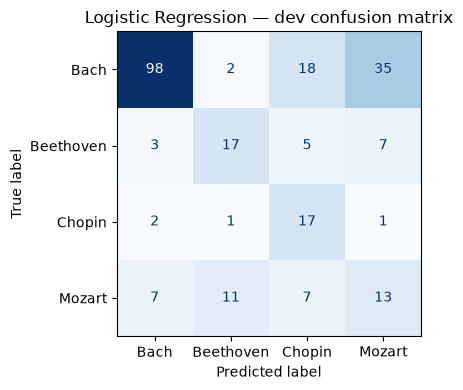


Registered: {'level': 'file', 'dev_accuracy': 0.5942622950819673, 'dev_macro_f1': 0.515381358163091, 'dev_per_class_recall': {'Bach': np.float64(0.641), 'Beethoven': np.float64(0.531), 'Chopin': np.float64(0.81), 'Mozart': np.float64(0.342)}}


<Figure size 640x480 with 0 Axes>

In [22]:
# Baseline: Logistic Regression on handcrafted features

# Prerequisite guard — fail fast with instructions, not a NameError
_missing = [name for name in
            ("X_feat_train", "y_feat_train", "X_feat_dev", "y_feat_dev",
             "lr_label_encoder", "SEED")
            if name not in globals()]
if _missing:
    raise RuntimeError(
        f"Missing prerequisites: {_missing}. "
        "Run the session-restore chain first: Cell 10 (imports) -> constants cell "
        "-> Cell 15 (load/split) -> Cell 28 (preprocessor) -> Cell 29 (fit) "
        "-> Cell 31 (feature engineering). "
        "Tip: select this cell and use Runtime -> Run before."
    )

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    recall_score,
)
from sklearn.dummy import DummyClassifier

class LogisticRegressionPipeline:
    """File-level composer baseline on the 8 handcrafted features.

    Note: X_feat_* are already standardized by the StandardScaler fitted
    in Section 4, so no scaling happens here.
    """

    def __init__(self, label_encoder, C=1.0):
        self.label_encoder = label_encoder
        self.model = LogisticRegression(
            C=C,
            max_iter=5000,               # default 100 often fails to converge
            class_weight="balanced",     # counter class imbalance at file level
            random_state=SEED,
        )

    def train(self, X, y):
        self.model.fit(X, y)
        return self

    def evaluate(self, X, y, split_name=""):
        """Full metrics bundle, reusable for dev and test."""
        preds = self.model.predict(X)
        return {
            "split": split_name,
            "accuracy": accuracy_score(y, preds),
            "macro_f1": f1_score(y, preds, average="macro"),
            "per_class_recall": dict(zip(
                self.label_encoder.classes_,
                recall_score(y, preds, average=None).round(3),
            )),
            "report": classification_report(
                y, preds, target_names=self.label_encoder.classes_, digits=3
            ),
            "confusion": confusion_matrix(y, preds),
            "predictions": preds,
        }

    def predict_composer_names(self, X):
        return self.label_encoder.inverse_transform(self.model.predict(X))


# Majority-class floor: the number every model must beat
dummy = DummyClassifier(strategy="most_frequent").fit(X_feat_train, y_feat_train)
floor_acc = accuracy_score(y_feat_dev, dummy.predict(X_feat_dev))
print(f"Majority-class floor (dev): {floor_acc:.4f}\n")

# Train and evaluate on dev
lr_pipe = LogisticRegressionPipeline(label_encoder=lr_label_encoder)
lr_pipe.train(X_feat_train, y_feat_train)

# Save trained model and label encoder for later use
import joblib

artifact_dir = Path("artifacts/preprocessed")
artifact_dir.mkdir(parents=True, exist_ok=True)
model_path = artifact_dir / "logistic_regression_model.joblib"
label_path = artifact_dir / "logistic_regression_label_encoder.joblib"
joblib.dump(lr_pipe.model, model_path)
joblib.dump(lr_label_encoder, label_path)
print(f"Saved model to: {model_path}")
print(f"Saved label encoder to: {label_path}")

val_result = lr_pipe.evaluate(X_feat_dev, y_feat_dev, split_name="dev")
print("Validation Accuracy:", round(val_result["accuracy"], 4))
print("Validation Macro-F1:", round(val_result["macro_f1"], 4))
print(f"(Majority-class floor: {floor_acc:.4f})")
print(val_result["report"])

# Confusion matrix: shows which composers the baseline confuses
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    val_result["confusion"], display_labels=lr_label_encoder.classes_
).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Logistic Regression — dev confusion matrix")
plt.tight_layout()
plt.show()
plt.savefig("artifacts/logistic_regression_confusion_matrix.png", dpi=300, bbox_inches="tight")

# Store for the Section 6 model comparison table.
# Schema shared by all model sections: dev_accuracy, dev_macro_f1,
# dev_per_class_recall (+ piece_ variants for the window-level models).
results_registry = globals().get("results_registry", {})
results_registry["majority_floor"] = {
    "level": "file",
    "dev_accuracy": float(floor_acc),
}
results_registry["logistic_regression"] = {
    "level": "file",
    "dev_accuracy": float(val_result["accuracy"]),
    "dev_macro_f1": float(val_result["macro_f1"]),
    "dev_per_class_recall": val_result["per_class_recall"],
}
print("\nRegistered:", results_registry["logistic_regression"])

### 5.2. LSTM Model Development
### Owner: Reema

In [ ]:
# Enter your code here to define the LSTM model architecture, including embedding/sequence layers, recurrent blocks, dropout, and a dense classifier. Make sure to keep the model definitions modular to facilitate ablation studies.

# LSTM model
# Input: X_lstm_train, X_lstm_dev, X_lstm_test
# Shape: (N, T, F) where T=1024 and F=128
# Labels: y_train, y_dev, y_test

### Training, Optimization, and Validation

In [ ]:

# Use early stopping and model checkpointing.
# Run controlled experiments across learning rate, batch size, depth, and dropout.
# Track every run with config, metrics, and notes.

### Evaluation and Error Analysis

In [ ]:
# Evaluate best models on hold-out test set.
# Report accuracy, precision, recall, F1-score, and confusion matrix.
# Analyze frequent misclassifications and class-specific weaknesses.

### 5.3. CNN Model Development
### Owner: Nicole

In [ ]:
# Enter your code here to define the CNN model architecture, including convolutional blocks, pooling layers, normalization, and a dense classifier. Make sure to keep the model definitions modular to facilitate ablation studies.

# CNN model
# Input: X_cnn_train, X_cnn_dev, X_cnn_test
# Shape: (N, H, W, C) = (N, 128, 1024, 1)
# Labels: y_train, y_dev, y_test

###  Training, Optimization and Validation

In [ ]:
# Use early stopping and model checkpointing.
# Run controlled experiments across learning rate, batch size, depth, and dropout.
# Track every run with config, metrics, and notes.

### Evaluation and Error Analysis

In [ ]:
# Evaluate best models on hold-out test set.
# Report accuracy, precision, recall, F1-score, and confusion matrix.
# Analyze frequent misclassifications and class-specific weaknesses.

## 6. Model Selection and Optimization
### Owner: Reema and Nicole
- Compare LSTM vs CNN against objective metrics and training stability.
- Select final model using both metric quality and robustness.
- Apply final hyperparameter tuning pass.

## 7. Packaging and Reproducibility
### Owner: Reema or Nicole depending on which model is selected.

In [ ]:
# Save preprocessing artifacts, label encoder, and model weights.
# Create an inference function for unseen music input.
# Document end-to-end run steps for reproducibility.

### Optional demo cell: predict composer for a sample input.

## 8. Final Deliverables
### Owner: Pros
- Final notebook with narrative and visual results.

### Owner: Team
- Final Report: problem, method, results, limitations, future work.
